# 04 — Geração dos pseudo-rótulos de triagem em 3 níveis

**Projeto:** Medical Triage MLOps  
**Modelo-base:** `Yuvrajxms09/biobert-triage-classifier`

## Objetivo

Aplicar o classificador pré-treinado a **todos os resumos médicos únicos** e gerar um novo dataset com três rótulos operacionais:

```text
normal
atenção
urgente
```

A adaptação segue a mesma regra validada no notebook anterior:

```text
urgent_score >= threshold      → urgente
nonurgent_score >= threshold   → normal
caso contrário                 → atenção
```

Neste projeto, a classe `atenção` representa uma **zona de incerteza do classificador binário**. Ela não é uma classe clínica originalmente aprendida pelo BioBERT.

> Uso acadêmico. Os pseudo-rótulos não constituem validação clínica.

## 1. Dependências

Se ainda não estiverem instaladas:

```bash
uv add transformers torch pandas matplotlib tqdm
uv sync
```

No VS Code, selecione o kernel Python da `.venv` do projeto.

In [1]:
from __future__ import annotations

from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoTokenizer, pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

MODEL_NAME = "Yuvrajxms09/biobert-triage-classifier"

# Mantemos a mesma regra testada no notebook 03.
CONFIDENCE_THRESHOLD = 0.70

# Parâmetros de inferência.
# 512 e o limite do BERT; com 256, 60% dos abstracts eram truncados.
MAX_LENGTH = 512
BATCH_SIZE = 16

# Salva resultados parciais a cada N textos.
CHECKPOINT_EVERY = 500

# Limite máximo de execução da etapa de inferência.
# Usamos uma margem de segurança para permitir o salvamento final.
MAX_RUNTIME_MINUTES = 30
SAFETY_MARGIN_SECONDS = 30
MAX_RUNTIME_SECONDS = (
    MAX_RUNTIME_MINUTES * 60
    - SAFETY_MARGIN_SECONDS
)

COLORS = {
    "normal": "#16A085",
    "atenção": "#F4B942",
    "urgente": "#D63031",
}

RANDOM_STATE = 42

## 2. Localização do projeto e carregamento dos dados

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, current.parent, current.parent.parent]:
        expected = candidate / "data" / "raw" / "medical_tc_train.csv"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Não encontrei data/raw/medical_tc_train.csv. "
        "Confira a estrutura de pastas do projeto."
    )


PROJECT_ROOT = locate_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "medical_tc_train.csv"
TEST_PATH = RAW_DIR / "medical_tc_test.csv"
LABELS_PATH = RAW_DIR / "medical_tc_labels.csv"

OUTPUT_PATH = PROCESSED_DIR / "medical_abstracts_triage_pseudolabeled.csv"
CHECKPOINT_PATH = PROCESSED_DIR / "medical_abstracts_triage_checkpoint.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
labels = pd.read_csv(LABELS_PATH)

print(f"Treino original: {len(train):,}")
print(f"Teste original:  {len(test):,}")
print(f"Total original:  {len(train) + len(test):,}")

Treino original: 11,550
Teste original:  2,888
Total original:  14,438


## 3. Consolidação por texto único

O EDA mostrou que alguns abstracts aparecem mais de uma vez e podem estar ligados a múltiplas categorias médicas.

Para evitar gerar pseudo-rótulos repetidos, agrupamos o corpus pelo texto e mantemos as categorias originais apenas para rastreabilidade.

In [3]:
label_map = dict(
    zip(
        labels["condition_label"],
        labels["condition_name"],
    )
)

combined = pd.concat(
    [
        train.assign(original_split="train"),
        test.assign(original_split="test"),
    ],
    ignore_index=True,
)

combined["medical_abstract"] = (
    combined["medical_abstract"]
    .astype(str)
    .str.strip()
)

unique_abstracts = (
    combined.groupby("medical_abstract")
    .agg(
        original_condition_labels=(
            "condition_label",
            lambda values: "|".join(
                map(str, sorted(set(values)))
            ),
        ),
        original_condition_names=(
            "condition_label",
            lambda values: "|".join(
                label_map[value]
                for value in sorted(set(values))
            ),
        ),
        original_splits=(
            "original_split",
            lambda values: "|".join(sorted(set(values))),
        ),
    )
    .reset_index()
    # O groupby ordena alfabeticamente; sem o shuffle, uma execucao parcial
    # processaria apenas os primeiros titulos do alfabeto (vies de selecao).
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Textos únicos para pseudo-rotulagem: {len(unique_abstracts):,}")
display(unique_abstracts.head())

Textos únicos para pseudo-rotulagem: 11,227


,medical_abstract,original_condition_labels,original_condition_names,original_splits
0,Esophageal and gastric endoscopy in critically ill patients. How can it help you? Bleeding from the upper gastrointe...,5,general pathological conditions,train
1,Extracorporeal shock wave lithotripsy of gallstones: results and 6-month follow-up in 141 patients. A study of bilia...,2,digestive system diseases,test
2,"Introduction: nutritional aspects of palm oil. The production, composition, and food uses of palm oil are outlined i...",1|4,neoplasms|cardiovascular diseases,train
3,Fixation of intertrochanteric fractures of the femur. A randomised prospective comparison of the gamma nail and the ...,5,general pathological conditions,test
4,Early cerebral infarction: gadopentetate dimeglumine enhancement Gadopentetate dimeglumine was administered prospect...,3,nervous system diseases,test


## 4. Carregamento e validação do BioBERT

Antes da inferência completa, conferimos novamente a configuração do checkpoint.

In [4]:
config = AutoConfig.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Modelo:", MODEL_NAME)
print("Arquitetura:", config.architectures)
print("Número de labels:", config.num_labels)
print("id2label:", config.id2label)
print("label2id:", config.label2id)

Modelo: Yuvrajxms09/biobert-triage-classifier
Arquitetura: ['BertForSequenceClassification']
Número de labels: 2
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}


### Dispositivo de execução

Se houver GPU CUDA disponível, ela será utilizada automaticamente. Caso contrário, a inferência será feita na CPU.

In [5]:
if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE = -1
    DEVICE_NAME = "CPU"

print(f"Dispositivo selecionado: {DEVICE_NAME}")

classifier = pipeline(
    task="text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE,
)

Dispositivo selecionado: NVIDIA GeForce RTX 5080


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 5. Funções auxiliares

Padronizamos os nomes dos labels retornados pelo checkpoint e implementamos a conversão para os três níveis de triagem.

In [6]:
def normalize_binary_label(label: str) -> str:
    normalized = str(label).strip().lower()

    if normalized in {"label_1", "1", "urgent"}:
        return "urgent"

    if normalized in {
        "label_0",
        "0",
        "non-urgent",
        "non_urgent",
        "nonurgent",
    }:
        return "non-urgent"

    return normalized


def parse_prediction(prediction_items):
    scores = {
        normalize_binary_label(item["label"]): float(item["score"])
        for item in prediction_items
    }

    urgent_score = scores.get("urgent", np.nan)
    nonurgent_score = scores.get("non-urgent", np.nan)

    if np.isnan(urgent_score) or np.isnan(nonurgent_score):
        raise ValueError(
            "Não foi possível identificar urgent/non-urgent. "
            f"Saída recebida: {prediction_items}"
        )

    binary_prediction = (
        "urgent"
        if urgent_score >= nonurgent_score
        else "non-urgent"
    )

    confidence = max(urgent_score, nonurgent_score)

    return (
        binary_prediction,
        urgent_score,
        nonurgent_score,
        confidence,
    )


def map_to_three_levels(
    urgent_score: float,
    nonurgent_score: float,
    threshold: float = CONFIDENCE_THRESHOLD,
) -> str:
    if urgent_score >= threshold:
        return "urgente"

    if nonurgent_score >= threshold:
        return "normal"

    return "atenção"

## 6. Análise do tamanho em tokens

O modelo recebe no máximo `MAX_LENGTH = 256` tokens por abstract. Textos maiores serão truncados.

Esse indicador será salvo no dataset final para manter a limitação transparente.

In [7]:
def token_count(text: str) -> int:
    return len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )


tqdm.pandas(desc="Contando tokens")

unique_abstracts["n_tokens"] = (
    unique_abstracts["medical_abstract"]
    .progress_apply(token_count)
)

unique_abstracts["was_truncated"] = (
    unique_abstracts["n_tokens"] > MAX_LENGTH
)

print(
    f"Textos acima de {MAX_LENGTH} tokens: "
    f"{unique_abstracts['was_truncated'].sum():,} "
    f"({unique_abstracts['was_truncated'].mean():.1%})"
)

Contando tokens:   0%|          | 0/11227 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors


Textos acima de 512 tokens: 618 (5.5%)


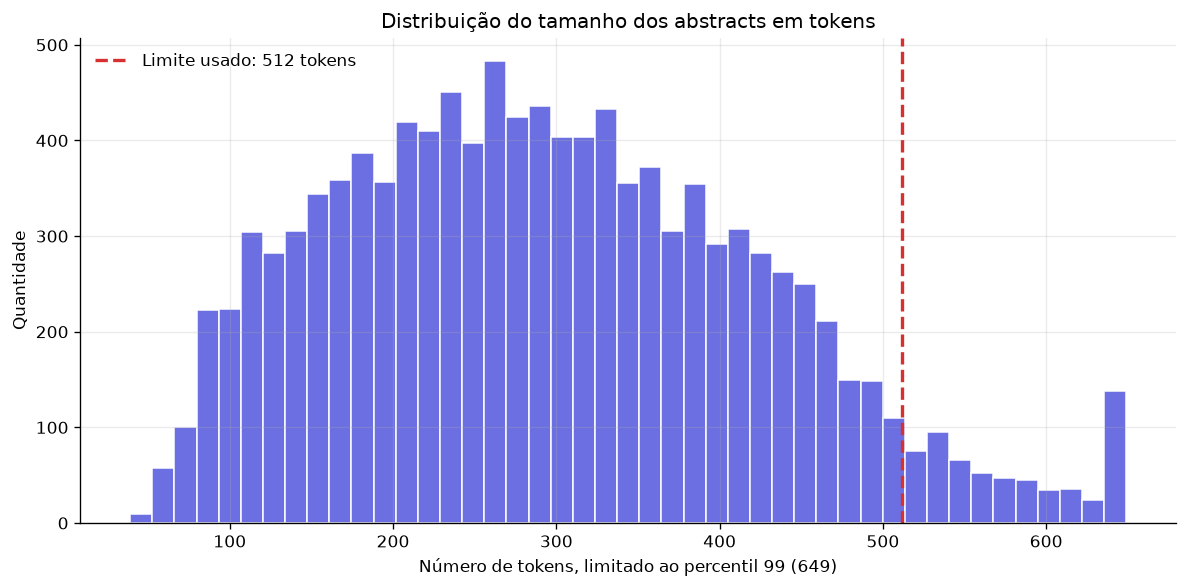

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_limit = int(
    unique_abstracts["n_tokens"].quantile(0.99)
)

ax.hist(
    unique_abstracts["n_tokens"].clip(upper=plot_limit),
    bins=45,
    color="#5B5FDE",
    edgecolor="white",
    alpha=0.9,
)

ax.axvline(
    MAX_LENGTH,
    color="#D63031",
    linestyle="--",
    linewidth=2,
    label=f"Limite usado: {MAX_LENGTH} tokens",
)

ax.set_title("Distribuição do tamanho dos abstracts em tokens")
ax.set_xlabel(f"Número de tokens, limitado ao percentil 99 ({plot_limit})")
ax.set_ylabel("Quantidade")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Inferência completa com checkpoints

A inferência é feita em lotes e possui **limite máximo de aproximadamente 30 minutos**.

O notebook também salva um arquivo parcial periodicamente. Ao atingir o limite de tempo, ele interrompe novos batches e salva tudo o que já foi processado.

In [9]:
def save_partial_results(
    result: pd.DataFrame,
    predictions: list,
    processed: int,
) -> None:
    """Salva os resultados processados até o momento."""
    if processed == 0:
        return

    partial = result.iloc[:processed].copy()

    parsed = [
        parse_prediction(item)
        for item in predictions
    ]

    partial[
        [
            "binary_prediction",
            "urgent_score",
            "nonurgent_score",
            "confidence",
        ]
    ] = pd.DataFrame(
        parsed,
        index=partial.index,
    )

    partial["triage_level"] = partial.apply(
        lambda row: map_to_three_levels(
            urgent_score=row["urgent_score"],
            nonurgent_score=row["nonurgent_score"],
        ),
        axis=1,
    )

    partial["pseudolabel_model"] = MODEL_NAME
    partial["pseudolabel_threshold"] = CONFIDENCE_THRESHOLD
    partial["max_length"] = MAX_LENGTH

    partial.to_csv(
        CHECKPOINT_PATH,
        index=False,
    )


def run_full_inference(
    dataframe: pd.DataFrame,
    batch_size: int = BATCH_SIZE,
    checkpoint_every: int = CHECKPOINT_EVERY,
) -> pd.DataFrame:
    """
    Executa a pseudo-rotulagem com limite de aproximadamente 30 minutos.

    A função verifica o tempo antes de iniciar cada novo batch.
    Ao atingir o limite, interrompe a inferência e salva os dados
    já processados no arquivo de checkpoint.
    """
    result = dataframe.copy()

    predictions = []
    processed = 0
    total = len(result)

    start_time = time.perf_counter()

    try:
        for start in tqdm(
            range(0, total, batch_size),
            desc="Pseudo-rotulando abstracts",
        ):
            elapsed = time.perf_counter() - start_time

            # Para antes dos 30 minutos, deixando margem para salvar.
            if elapsed >= MAX_RUNTIME_SECONDS:
                print(
                    "\nLimite de tempo atingido."
                    f"\nTempo executado: {elapsed / 60:.2f} minutos"
                    f"\nRegistros processados: {processed:,}/{total:,}"
                )
                break

            end = min(
                start + batch_size,
                total,
            )

            batch_texts = (
                result
                .iloc[start:end]["medical_abstract"]
                .tolist()
            )

            batch_predictions = classifier(
                batch_texts,
                batch_size=batch_size,
                truncation=True,
                max_length=MAX_LENGTH,
                top_k=None,
            )

            predictions.extend(batch_predictions)
            processed = end

            # Checkpoint periódico.
            if (
                processed % checkpoint_every < batch_size
                or processed == total
            ):
                save_partial_results(
                    result=result,
                    predictions=predictions,
                    processed=processed,
                )

    except KeyboardInterrupt:
        print(
            "\nExecução interrompida manualmente."
            "\nSalvando o progresso atual..."
        )

    # Mantém somente os registros realmente processados.
    partial_result = result.iloc[:processed].copy()

    if processed == 0:
        print("Nenhum registro foi processado.")
        return partial_result

    parsed = [
        parse_prediction(item)
        for item in predictions
    ]

    partial_result[
        [
            "binary_prediction",
            "urgent_score",
            "nonurgent_score",
            "confidence",
        ]
    ] = pd.DataFrame(
        parsed,
        index=partial_result.index,
    )

    partial_result["triage_level"] = partial_result.apply(
        lambda row: map_to_three_levels(
            urgent_score=row["urgent_score"],
            nonurgent_score=row["nonurgent_score"],
        ),
        axis=1,
    )

    partial_result["pseudolabel_model"] = MODEL_NAME
    partial_result["pseudolabel_threshold"] = CONFIDENCE_THRESHOLD
    partial_result["max_length"] = MAX_LENGTH

    elapsed = time.perf_counter() - start_time

    # Sempre salva o resultado processado ao encerrar.
    partial_result.to_csv(
        CHECKPOINT_PATH,
        index=False,
    )

    print("\nExecução finalizada.")
    print(f"Tempo: {elapsed / 60:.2f} minutos")
    print(f"Processados: {processed:,}/{total:,}")

    if elapsed > 0:
        print(
            f"Velocidade média: "
            f"{processed / elapsed:.2f} textos/s"
        )

    if processed < total:
        print(
            f"Faltaram {total - processed:,} registros."
        )
        print(
            f"Resultados parciais salvos em: {CHECKPOINT_PATH}"
        )
    else:
        print("Todo o dataset foi processado.")

    return partial_result

### Executar pseudo-rotulagem

> Esta célula pode demorar, especialmente em CPU. A execução é interrompida automaticamente após aproximadamente **30 minutos**, com uma pequena margem para salvar os resultados.

In [10]:
pseudolabeled = run_full_inference(
    unique_abstracts,
    batch_size=BATCH_SIZE,
)

print(f"Pseudo-rótulos gerados: {len(pseudolabeled):,}")

Pseudo-rotulando abstracts:   0%|          | 0/702 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Execução finalizada.
Tempo: 0.99 minutos
Processados: 11,227/11,227
Velocidade média: 189.21 textos/s
Todo o dataset foi processado.
Pseudo-rótulos gerados: 11,227


## 8. Validação básica do resultado

Verificamos se:

- todos os registros receberam scores;
- os scores estão no intervalo esperado;
- todas as classes finais pertencem ao conjunto permitido.

In [11]:
allowed_labels = {"normal", "atenção", "urgente"}

checks = {
    "linhas": len(pseudolabeled),
    "urgent_score_nulos": int(
        pseudolabeled["urgent_score"].isna().sum()
    ),
    "nonurgent_score_nulos": int(
        pseudolabeled["nonurgent_score"].isna().sum()
    ),
    "confidence_nulos": int(
        pseudolabeled["confidence"].isna().sum()
    ),
    "labels_invalidos": int(
        (~pseudolabeled["triage_level"].isin(allowed_labels)).sum()
    ),
}

display(
    pd.DataFrame(
        checks.items(),
        columns=["verificação", "resultado"],
    )
)

assert checks["urgent_score_nulos"] == 0
assert checks["nonurgent_score_nulos"] == 0
assert checks["confidence_nulos"] == 0
assert checks["labels_invalidos"] == 0

print("Validações concluídas.")

,verificação,resultado
0,linhas,11227
1,urgent_score_nulos,0
2,nonurgent_score_nulos,0
3,confidence_nulos,0
4,labels_invalidos,0


Validações concluídas.


## 9. Distribuição dos pseudo-rótulos

In [12]:
order = ["normal", "atenção", "urgente"]

distribution = (
    pseudolabeled["triage_level"]
    .value_counts()
    .reindex(order, fill_value=0)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)

distribution["percentual"] = (
    distribution["quantidade"]
    / len(pseudolabeled)
)

display(distribution)

,classe,quantidade,percentual
0,normal,5000,0.4454
1,atenção,4873,0.4340
2,urgente,1354,0.1206


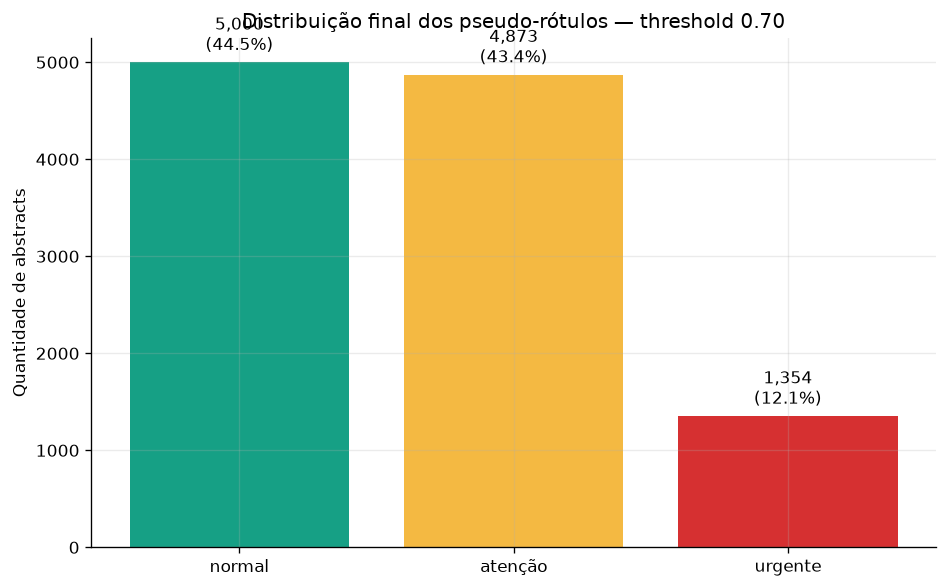

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    distribution["classe"],
    distribution["quantidade"],
    color=[
        COLORS[label]
        for label in distribution["classe"]
    ],
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,}\n({pct:.1%})"
        for count, pct in zip(
            distribution["quantidade"],
            distribution["percentual"],
        )
    ],
    padding=4,
)

ax.set_title(
    f"Distribuição final dos pseudo-rótulos — threshold {CONFIDENCE_THRESHOLD:.2f}"
)
ax.set_ylabel("Quantidade de abstracts")

plt.tight_layout()
plt.show()

## 10. Distribuição do score de urgência

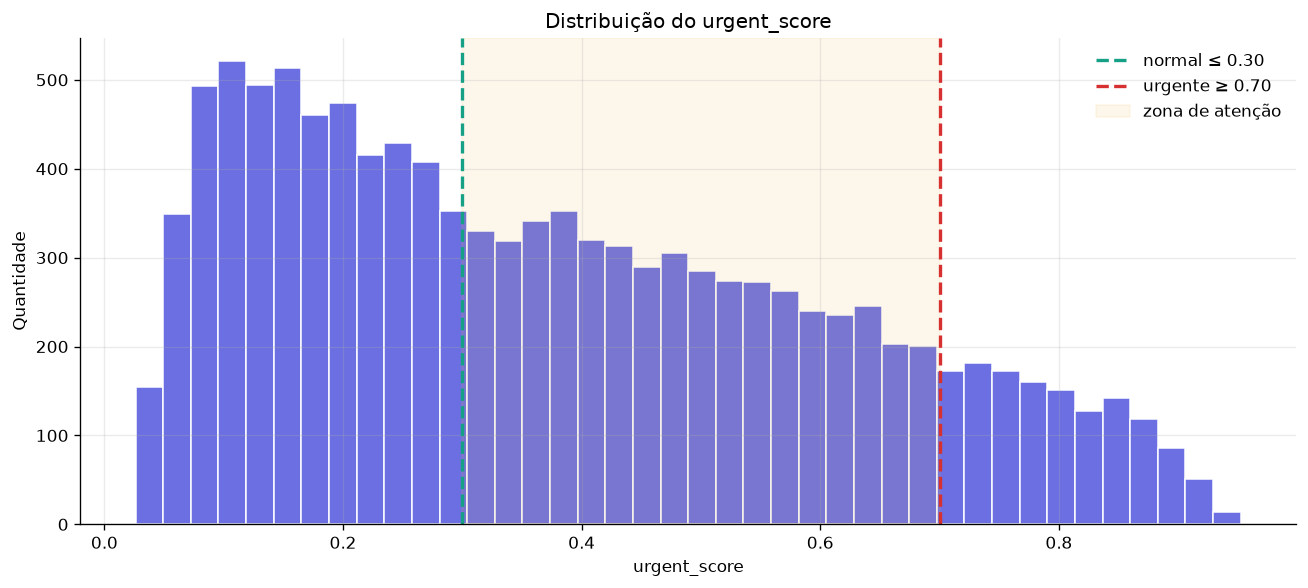

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    pseudolabeled["urgent_score"],
    bins=40,
    color="#5B5FDE",
    edgecolor="white",
    alpha=0.9,
)

lower_boundary = 1 - CONFIDENCE_THRESHOLD
upper_boundary = CONFIDENCE_THRESHOLD

ax.axvline(
    lower_boundary,
    color=COLORS["normal"],
    linestyle="--",
    linewidth=2,
    label=f"normal ≤ {lower_boundary:.2f}",
)

ax.axvline(
    upper_boundary,
    color=COLORS["urgente"],
    linestyle="--",
    linewidth=2,
    label=f"urgente ≥ {upper_boundary:.2f}",
)

ax.axvspan(
    lower_boundary,
    upper_boundary,
    color=COLORS["atenção"],
    alpha=0.10,
    label="zona de atenção",
)

ax.set_title("Distribuição do urgent_score")
ax.set_xlabel("urgent_score")
ax.set_ylabel("Quantidade")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 11. Confiança por classe final

In [15]:
confidence_summary = (
    pseudolabeled.groupby("triage_level")["confidence"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
    )
    .reindex(order)
)

display(confidence_summary)

,quantidade,media,mediana,minimo,maximo
triage_level,,,,,
normal,5000,0.8327,0.8362,0.7000,0.9738
atenção,4873,0.5989,0.5996,0.5001,0.7000
urgente,1354,0.7986,0.7928,0.7002,0.9524


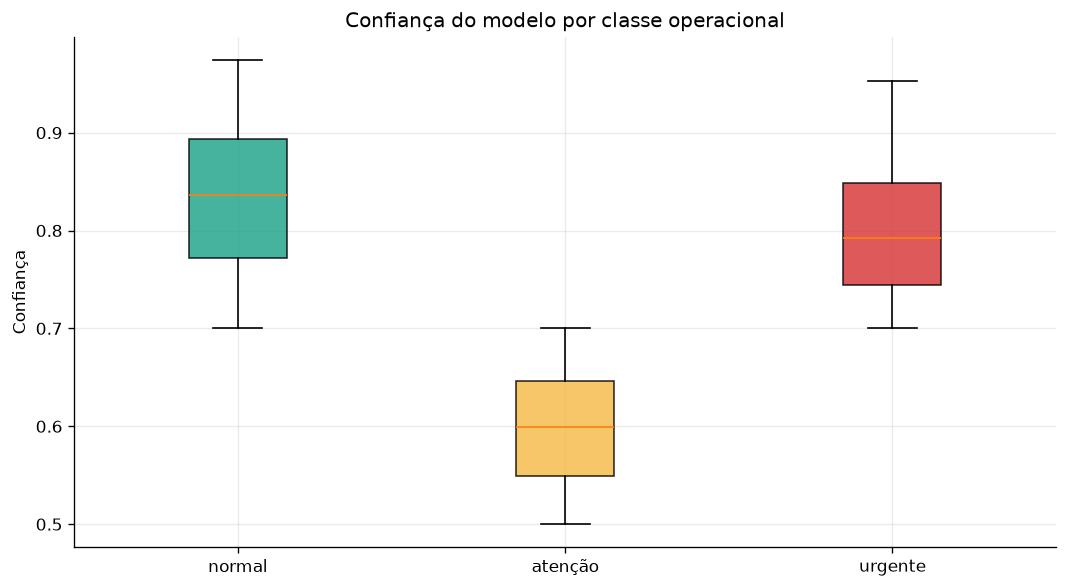

In [16]:
confidence_data = [
    pseudolabeled.loc[
        pseudolabeled["triage_level"] == label,
        "confidence",
    ]
    for label in order
]

fig, ax = plt.subplots(figsize=(9, 5))

box = ax.boxplot(
    confidence_data,
    tick_labels=order,
    patch_artist=True,
    showfliers=False,
)

for patch, label in zip(box["boxes"], order):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.8)

ax.set_title("Confiança do modelo por classe operacional")
ax.set_ylabel("Confiança")

plt.tight_layout()
plt.show()

## 12. Exemplos extremos e casos de atenção

Nesta etapa fazemos uma inspeção qualitativa dos pseudo-rótulos.

In [17]:
display(Markdown("### Mais urgentes segundo o modelo"))

display(
    pseudolabeled.nlargest(10, "urgent_score")
    [
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "triage_level",
            "was_truncated",
        ]
    ]
)

### Mais urgentes segundo o modelo

,medical_abstract,urgent_score,nonurgent_score,triage_level,was_truncated
3119,Spontaneous rupture of the spleen in initial presentation of Hodgkin's disease. A 46-year-old man presented with a f...,0.9524,0.0476,urgente,False
6654,Evaluation and management of supraventricular tachycardia in children. Emergency physicians may be called on to resu...,0.9493,0.0507,urgente,False
6893,Traumatic rupture of the thoracic aorta presenting as transient paraplegia. A patient involved in a high-speed motor...,0.9400,0.0600,urgente,False
4261,Crico-tracheal disruption and common carotid artery occlusion: a case of blunt trauma. A case of blunt trauma to the...,0.9396,0.0604,urgente,False
8334,Spontaneous rupture of the stomach in an adult. We have reported a case of spontaneous rupture of the stomach in an ...,0.9382,0.0618,urgente,False
10768,Emergent aneurysm surgery without cerebral angiography for the comatose patient Neurologically based clinical gradin...,0.9365,0.0635,urgente,False
6610,"Poisoning with equine phenylbutazone in a racetrack worker. Phenylbutazone is a potent nonsteroidal, anti-inflammato...",0.9346,0.0654,urgente,False
5086,Miliary tuberculosis presenting as hepatic and renal failure. A 67-year-old man developed hepatic and renal failure ...,0.9340,0.0660,urgente,False
4655,Methylene iodide poisoning. A 20-month-old girl ingested a maximum of 25 mL of pure methylene iodide. Within two hou...,0.9328,0.0672,urgente,False
7349,Intercostal arteriovenous fistula due to pleural biopsy A 32 year old woman had a pleural biopsy for a left pleural ...,0.9314,0.0686,urgente,False


In [18]:
display(Markdown("### Mais normais segundo o modelo"))

display(
    pseudolabeled.nsmallest(10, "urgent_score")
    [
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "triage_level",
            "was_truncated",
        ]
    ]
)

### Mais normais segundo o modelo

,medical_abstract,urgent_score,nonurgent_score,triage_level,was_truncated
2069,Does cholesterol screening result in negative labeling effects? Results of the Massachusetts Model Systems for Blood...,0.0262,0.9738,normal,False
10393,Needs and recommendations for behavior research in the prevention and early detection of cancer. Because life-style ...,0.0288,0.9712,normal,False
10884,"A perspective on reducing salt intake. Epidemiological, clinical, and experimental evidence links excessive salt con...",0.0298,0.9702,normal,False
7991,Are people more health conscious? A longitudinal study of one community. Secular changes in cardiovascular health aw...,0.0310,0.9690,normal,False
7733,A provider's view of prevention approaches in a prepaid group practice. Kaiser Permanente's health care delivery sys...,0.0329,0.9671,normal,False
6975,How stressful is retirement? Findings from the Normative Aging Study. The stressfulness of retirement both as a tran...,0.0330,0.9670,normal,False
4661,Stressful events and life satisfaction among elderly men and women. The purpose of this study was to examine the int...,0.0331,0.9669,normal,False
209,"A longitudinal study of respiratory symptoms in a community population sample. Correlations with smoking, allergen s...",0.0335,0.9665,normal,False
4404,Job dimensions associated with severe disability due to cardiovascular disease. This study explored associations amo...,0.0335,0.9665,normal,False
9092,Research in physical medicine and rehabilitation. XII. Measurement tools with application to brain injury. There are...,0.0336,0.9664,normal,False


In [19]:
display(Markdown("### Casos mais próximos de 0.50"))

attention_review = (
    pseudolabeled.loc[
        pseudolabeled["triage_level"] == "atenção"
    ]
    .assign(
        distance_from_middle=lambda df: (
            df["urgent_score"] - 0.5
        ).abs()
    )
    .sort_values("distance_from_middle")
)

display(
    attention_review[
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "confidence",
            "was_truncated",
        ]
    ].head(15)
)

### Casos mais próximos de 0.50

,medical_abstract,urgent_score,nonurgent_score,confidence,was_truncated
1614,Predictors of long-term survival after percutaneous aortic valvuloplasty: report of the Mansfield Scientific Balloon...,0.5001,0.4999,0.5001,False
9387,Plasma immunoreactive leukotriene C4 levels in patients with Kawasaki disease. The incidence of wheezing in Kawasaki...,0.5001,0.4999,0.5001,False
2505,Demonstration of two distinct subsets of gastric varices. Observations during a seven-year study of endoscopic scler...,0.5001,0.4999,0.5001,False
3797,A newly recognized fastidious gram-negative pathogen as a cause of fever and bacteremia BACKGROUND. We identified a ...,0.5001,0.4999,0.5001,False
8912,Acute hemodynamic effects of captopril in children with a congestive or restrictive cardiomyopathy The acute hemodyn...,0.4998,0.5002,0.5002,False
8003,Bilateral homonymous visual field defects as initial manifestation of multiple sclerosis. Symptomatic suprageniculat...,0.4998,0.5002,0.5002,False
10734,Creutzfeldt-Jakob disease from allogeneic dura: a review of risks and safety. Surgeons and the lay public have recen...,0.5003,0.4997,0.5003,False
1852,A comparative trial of three agents in the treatment of acute migraine headache. STUDY OBJECTIVES: A study was condu...,0.5003,0.4997,0.5003,False
4120,Malignant melanoma of the oral cavity. A case report. The oral cavity is a rare location for the development of prim...,0.5003,0.4997,0.5003,False
6965,Persistent mullerian duct syndrome. Persistent mullerian syndrome is rare. A case of phenotypically normal male with...,0.4996,0.5004,0.5004,False


## 13. Relação com as categorias médicas originais

Esta análise é apenas descritiva.

Ela ajuda a verificar se o modelo está associando certas categorias originais de forma excessiva à urgência.

In [20]:
exploded_categories = pseudolabeled[
    [
        "original_condition_names",
        "triage_level",
    ]
].copy()

exploded_categories["original_condition_names"] = (
    exploded_categories["original_condition_names"]
    .str.split("|")
)

# pandas 3: o crosstab exige indice sem duplicatas apos o explode.
exploded_categories = exploded_categories.explode(
    "original_condition_names"
).reset_index(drop=True)

category_triage = pd.crosstab(
    exploded_categories["original_condition_names"],
    exploded_categories["triage_level"],
    normalize="index",
)

category_triage = category_triage.reindex(
    columns=order,
    fill_value=0,
)

display(category_triage)

triage_level,normal,atenção,urgente
original_condition_names,,,
cardiovascular diseases,0.4038,0.4277,0.1685
digestive system diseases,0.4465,0.4096,0.1439
general pathological conditions,0.3975,0.4447,0.1578
neoplasms,0.3794,0.5454,0.0752
nervous system diseases,0.5190,0.3501,0.1309


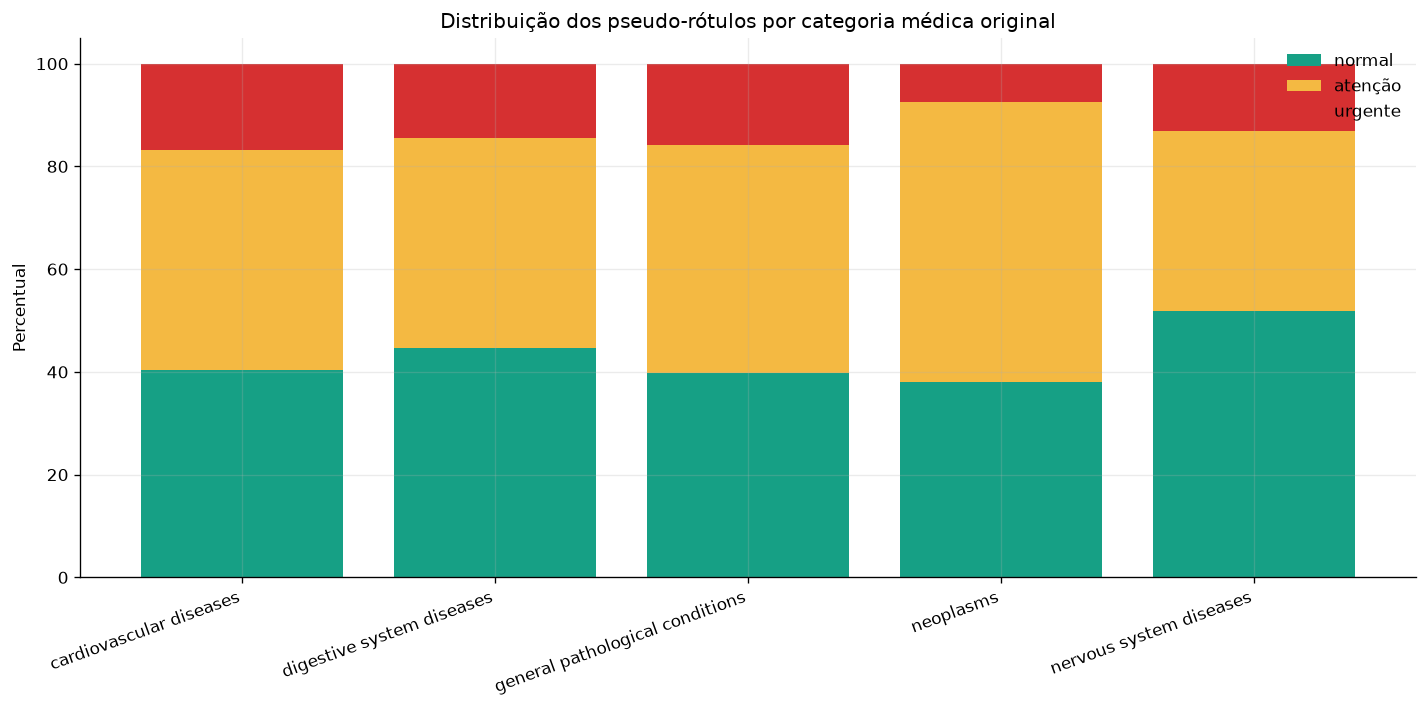

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(category_triage))

for triage_class in order:
    values = category_triage[triage_class].values * 100

    ax.bar(
        category_triage.index,
        values,
        bottom=bottom,
        label=triage_class,
        color=COLORS[triage_class],
    )

    bottom += values

ax.set_title("Distribuição dos pseudo-rótulos por categoria médica original")
ax.set_ylabel("Percentual")
ax.set_xlabel("")
ax.set_xticklabels(
    category_triage.index,
    rotation=20,
    ha="right",
)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 14. Dataset final para o próximo estágio

Mantemos no arquivo final:

- texto;
- pseudo-rótulo de triagem;
- probabilidades do BioBERT;
- confiança;
- indicação de truncamento;
- categorias médicas originais;
- modelo e threshold utilizados.

Isso melhora a rastreabilidade do experimento.

In [22]:
final_columns = [
    "medical_abstract",
    "triage_level",
    "urgent_score",
    "nonurgent_score",
    "confidence",
    "binary_prediction",
    "n_tokens",
    "was_truncated",
    "original_condition_labels",
    "original_condition_names",
    "original_splits",
    "pseudolabel_model",
    "pseudolabel_threshold",
    "max_length",
]

final_dataset = pseudolabeled[final_columns].copy()

final_dataset.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Dataset salvo em: {OUTPUT_PATH}")
print(f"Registros: {len(final_dataset):,}")

display(final_dataset.head())

Dataset salvo em: C:\Users\erick\projetos\medical-triage-mlops\data\processed\medical_abstracts_triage_pseudolabeled.csv
Registros: 11,227


,medical_abstract,triage_level,urgent_score,nonurgent_score,confidence,binary_prediction,n_tokens,was_truncated,original_condition_labels,original_condition_names,original_splits,pseudolabel_model,pseudolabel_threshold,max_length
0,Esophageal and gastric endoscopy in critically ill patients. How can it help you? Bleeding from the upper gastrointe...,atenção,0.6152,0.3848,0.6152,urgent,76,False,5,general pathological conditions,train,Yuvrajxms09/biobert-triage-classifier,0.7000,512
1,Extracorporeal shock wave lithotripsy of gallstones: results and 6-month follow-up in 141 patients. A study of bilia...,normal,0.2187,0.7813,0.7813,non-urgent,366,False,2,digestive system diseases,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512
2,"Introduction: nutritional aspects of palm oil. The production, composition, and food uses of palm oil are outlined i...",normal,0.0509,0.9491,0.9491,non-urgent,125,False,1|4,neoplasms|cardiovascular diseases,train,Yuvrajxms09/biobert-triage-classifier,0.7000,512
3,Fixation of intertrochanteric fractures of the femur. A randomised prospective comparison of the gamma nail and the ...,normal,0.2844,0.7156,0.7156,non-urgent,193,False,5,general pathological conditions,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512
4,Early cerebral infarction: gadopentetate dimeglumine enhancement Gadopentetate dimeglumine was administered prospect...,atenção,0.6471,0.3529,0.6471,urgent,313,False,3,nervous system diseases,test,Yuvrajxms09/biobert-triage-classifier,0.7000,512


## 15. Verificação final antes do MLP

In [23]:
print("Distribuição final:")
print(
    final_dataset["triage_level"]
    .value_counts()
    .reindex(["normal", "atenção", "urgente"])
)

print("\nTextos duplicados:")
print(
    final_dataset["medical_abstract"]
    .duplicated()
    .sum()
)

print("\nValores nulos relevantes:")
print(
    final_dataset[
        [
            "medical_abstract",
            "triage_level",
            "urgent_score",
            "nonurgent_score",
        ]
    ]
    .isna()
    .sum()
)

Distribuição final:
triage_level
normal     5000
atenção    4873
urgente    1354
Name: count, dtype: int64

Textos duplicados:
0

Valores nulos relevantes:
medical_abstract    0
triage_level        0
urgent_score        0
nonurgent_score     0
dtype: int64


## 16. Conclusão

Ao final deste notebook, os textos processados dentro do limite de execução passam a possuir uma variável de triagem operacional:

```text
medical_abstract → normal | atenção | urgente
```

A origem dos rótulos deve permanecer explícita:

- `normal`: alta confiança do BioBERT em `non-urgent`;
- `urgente`: alta confiança do BioBERT em `urgent`;
- `atenção`: zona intermediária de incerteza definida pelo projeto.

### Próximo notebook

```text
05_prepare_train_validation_test.ipynb
```

No próximo passo iremos:

1. carregar o dataset pseudo-rotulado;
2. analisar o equilíbrio das três classes;
3. criar uma divisão estratificada;
4. garantir ausência de vazamento de textos;
5. salvar treino, validação e teste;
6. preparar os dados para o `TF-IDF + MLPClassifier`.

Depois dele, partiremos para o treinamento do MLP.